# Ironman Race Results Analysis

This notebook demonstrates how to scrape, clean, analyze, and visualize Ironman race results. The workflow includes data extraction, cleaning, transformation, analysis, and visualization of performance trends.

In [41]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re

## Clean and Transform Race Data

In this section, we will process the raw data to add columns for gender and convert finish times to seconds for analysis.

In [42]:
# Load all sheets from the Excel file into separate DataFrames

def load_ironman_sheets(excel_path):
    """
    Load all sheets from the Ironman Excel file into a dictionary of DataFrames.
    Drops the sheet named 'hiddensheet' if present.
    Returns: dict of {sheet_name: DataFrame}
    """
    all_sheets = pd.read_excel(excel_path, sheet_name=None)
    if 'hiddenSheet' in all_sheets:
        print("Dropping sheet: hiddenSheet")
        all_sheets.pop('hiddenSheet')
    for name, df in all_sheets.items():
        print(f"Loaded sheet: {name} (rows: {len(df)})")
    return all_sheets

# Usage example:
excel_path = '../data/Ironman_RaceResults.xlsx'
sheets = load_ironman_sheets(excel_path)

c:\Users\jhigh\Projects\triathlon-db\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Dropping sheet: hiddenSheet
Loaded sheet: IM Lake Placid (rows: 3791)
Loaded sheet: IM Arizona (rows: 3059)
Loaded sheet: IM Chattanooga (rows: 2855)
Loaded sheet: IM Texas (rows: 5994)


In [43]:
# Add Gender and Finish Time (Seconds) Columns

def parse_time_to_seconds(time_str):
    """Convert a time string (e.g., '8:15:30') to seconds."""
    if pd.isnull(time_str):
        return np.nan
    parts = str(time_str).split(':')
    if len(parts) == 3:
        h, m, s = parts
    elif len(parts) == 2:
        h, m, s = 0, parts[0], parts[1]
    else:
        return np.nan
    try:
        return int(h) * 3600 + int(m) * 60 + float(s)
    except Exception:
        return np.nan
    
def extract_year(event_str):
    """Extracts a 4-digit year from the event string."""
    match = re.search(r'(20\d{2})', str(event_str))
    if match:
        return int(match.group(1))
    return np.nan

def infer_gender_from_age_group(age_group):
    """Infer gender from Age Group code (F=Female, M=Male, else Unknown)."""
    if isinstance(age_group, str):
        if age_group.startswith('F'):
            return 'Female'
        elif age_group.startswith('M'):
            return 'Male'
    return 'Unknown'


Summary Table for IM Lake Placid


Gender,Female,Male
Percent,,
4,7,9
5,10,13
6,12,15
7,14,16
8,15,21
9,15,22
10,17,28


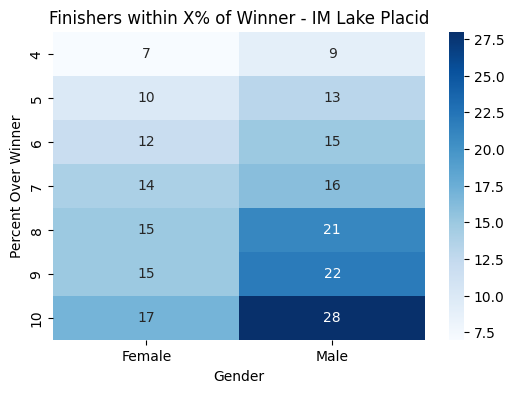


Summary Table for IM Arizona


Gender,Female,Male
Percent,,
4,6,3
5,6,4
6,9,5
7,12,10
8,16,13
9,22,14
10,26,15


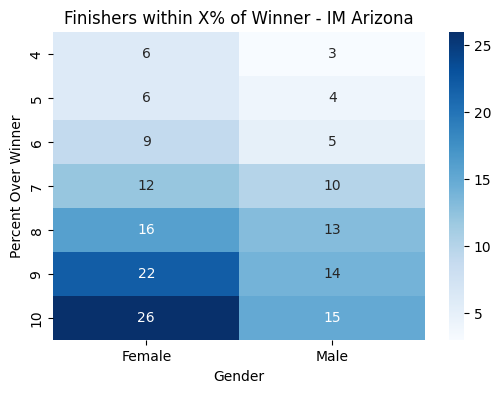


Summary Table for IM Chattanooga


Gender,Female,Male
Percent,,
4,5,8
5,6,9
6,6,11
7,7,13
8,10,13
9,11,14
10,13,17


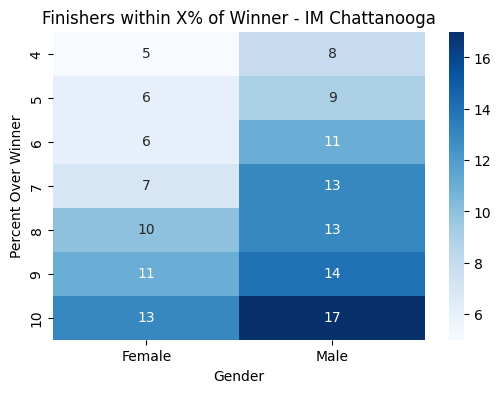


Summary Table for IM Texas


Gender,Female,Male
Percent,,
4,3,8
5,5,14
6,6,18
7,8,25
8,12,29
9,16,34
10,19,43


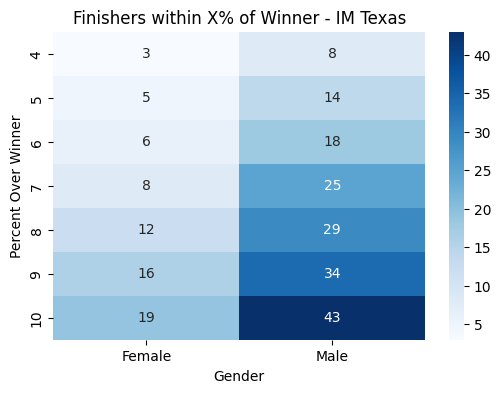

In [45]:
# Visualize and summarize the number of finishers within each percentage for each race

# Create a summary table for each race (event)
for event in results_df['Event'].unique():
    display_df = results_df[results_df['Event'] == event].pivot(index='Percent', columns='Gender', values='NumFinishers')
    print(f"\nSummary Table for {event}")
    display(display_df)
    # Optional: Heatmap visualization
    plt.figure(figsize=(6, 4))
    sns.heatmap(display_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Finishers within X% of Winner - {event}')
    plt.ylabel('Percent Over Winner')
    plt.xlabel('Gender')
    plt.show()

In [49]:
# Calculate number of finishers within 4% to 10% of the winner's time for each gender, event, and year

results = []
percentiles = list(range(4, 11))  # 4,5,6,7,8,9,10

def get_top_finishers(df, gender, percent):
    df_gender = df[df['Gender'] == gender].copy()
    if df_gender.empty or 'FinishSeconds' not in df_gender.columns:
        return 0
    winner_time = df_gender['FinishSeconds'].min()
    if pd.isnull(winner_time):
        return 0
    cutoff = winner_time * (1 + percent / 100)
    return (df_gender['FinishSeconds'] <= cutoff).sum()

for sheet_name, df in sheets.items():
    # Ensure required columns exist
    if 'FinishSeconds' not in df.columns or 'Gender' not in df.columns or 'Year' not in df.columns:
        continue
    for year in sorted(df['Year'].dropna().unique()):
        df_year = df[df['Year'] == year]
        for gender in ['Male', 'Female']:
            for pct in percentiles:
                count = get_top_finishers(df_year, gender, pct)
                results.append({
                    'Event': sheet_name,
                    'Year': int(year),
                    'Gender': gender,
                    'Percent': pct,
                    'NumFinishers': count
                })

results_df = pd.DataFrame(results)


Summary Table for IM Lake Placid (2023)


Gender,Female,Male
Percent,,
4,6,5
5,6,6
6,6,9
7,7,9
8,7,12
9,11,12
10,11,13


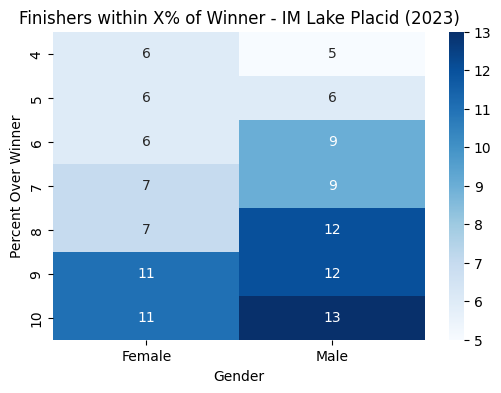


Summary Table for IM Lake Placid (2024)


Gender,Female,Male
Percent,,
4,5,6
5,7,8
6,7,10
7,8,10
8,9,12
9,9,13
10,10,16


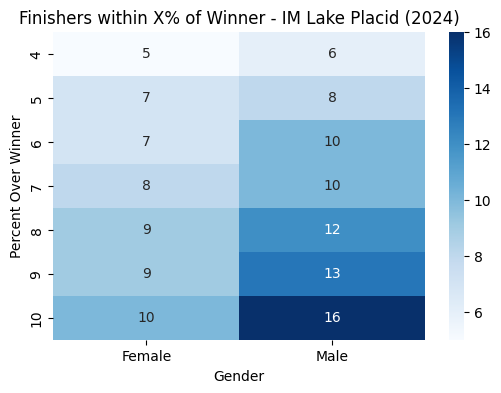


Summary Table for IM Arizona (2023)


Gender,Female,Male
Percent,,
4,4,1
5,4,1
6,6,5
7,7,7
8,10,9
9,15,10
10,18,16


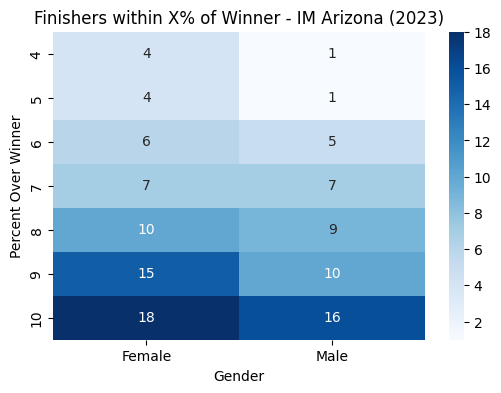


Summary Table for IM Arizona (2024)


Gender,Female,Male
Percent,,
4,5,2
5,6,3
6,7,4
7,8,5
8,8,6
9,11,6
10,13,6


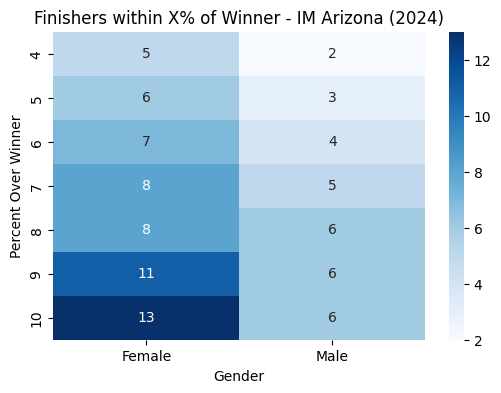


Summary Table for IM Chattanooga (2023)


Gender,Female,Male
Percent,,
4,4,1
5,8,2
6,9,2
7,11,3
8,13,7
9,16,8
10,17,9


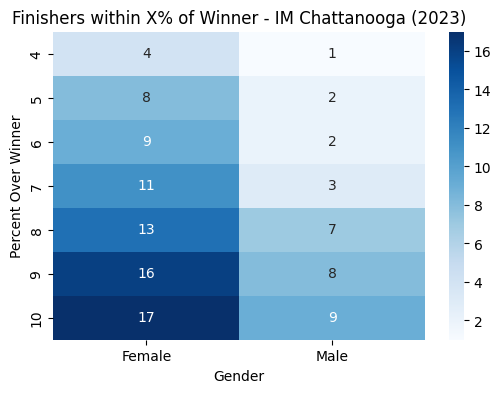


Summary Table for IM Chattanooga (2024)


Gender,Female,Male
Percent,,
4,5,8
5,6,9
6,6,11
7,7,13
8,10,13
9,11,14
10,13,17


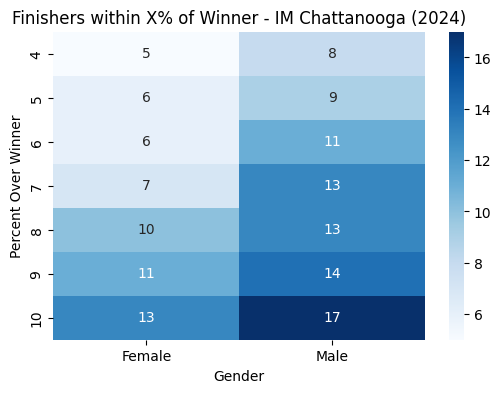


Summary Table for IM Texas (2023)


Gender,Female,Male
Percent,,
4,4,6
5,5,10
6,5,10
7,7,12
8,7,14
9,8,15
10,9,17


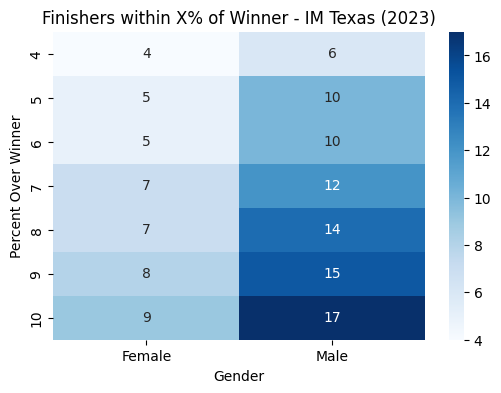


Summary Table for IM Texas (2024)


Gender,Female,Male
Percent,,
4,7,8
5,8,11
6,9,14
7,10,16
8,12,17
9,13,22
10,17,24


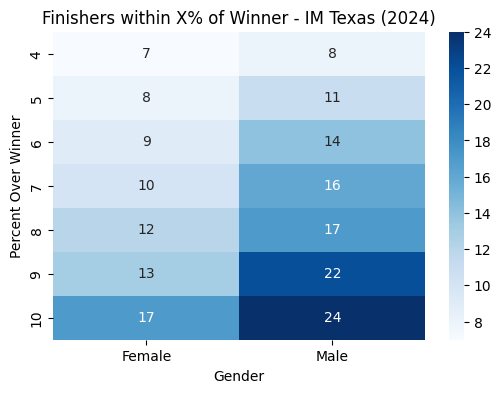


Summary Table for IM Texas (2025)


Gender,Female,Male
Percent,,
4,3,8
5,3,10
6,4,12
7,4,16
8,6,17
9,7,18
10,8,21


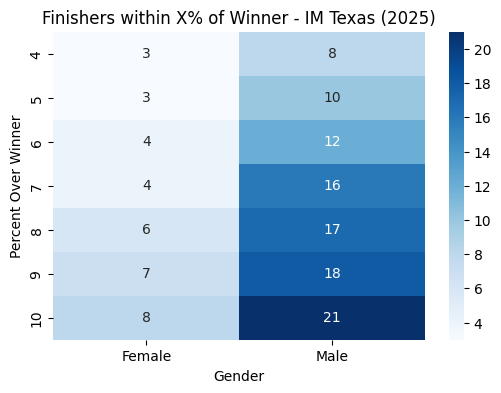

In [47]:
# Visualize and summarize by event, year, and gender
for (event, year) in results_df[['Event', 'Year']].drop_duplicates().itertuples(index=False):
    display_df = results_df[(results_df['Event'] == event) & (results_df['Year'] == year)]\
        .pivot(index='Percent', columns='Gender', values='NumFinishers')
    print(f"\nSummary Table for {event} ({year})")
    display(display_df)
    plt.figure(figsize=(6, 4))
    sns.heatmap(display_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Finishers within X% of Winner - {event} ({year})')
    plt.ylabel('Percent Over Winner')
    plt.xlabel('Gender')
    plt.show()


Summary Table for All Events in 2023


Gender,Female,Male
Percent,,
4,18,13
5,23,19
6,26,26
7,32,31
8,37,42
9,50,45
10,55,55


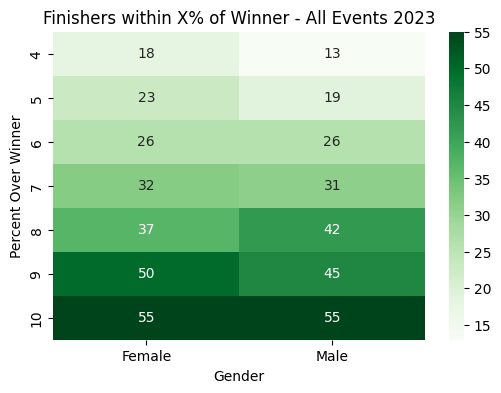


Summary Table for All Events in 2024


Gender,Female,Male
Percent,,
4,22,24
5,27,31
6,29,39
7,33,44
8,39,48
9,44,55
10,53,63


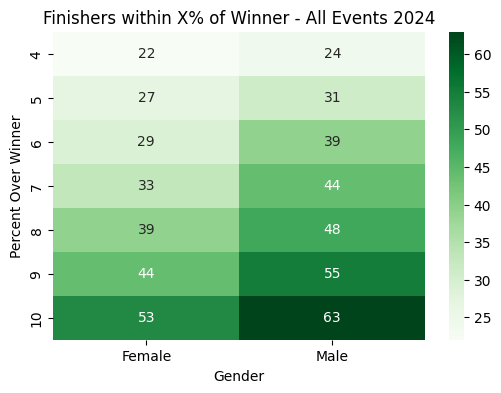

In [50]:
# Summary tables for all of 2023 and all of 2024 (across all events)
for year in [2023, 2024]:
    year_df = results_df[results_df['Year'] == year]
    if year_df.empty:
        print(f"No data for {year}")
        continue
    summary = year_df.groupby(['Percent', 'Gender'])['NumFinishers'].sum().unstack()
    print(f"\nSummary Table for All Events in {year}")
    display(summary)
    plt.figure(figsize=(6, 4))
    sns.heatmap(summary, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Finishers within X% of Winner - All Events {year}')
    plt.ylabel('Percent Over Winner')
    plt.xlabel('Gender')
    plt.show()

# Export options:
# 1. CSV: results_df.to_csv('ironman_finishers_summary.csv', index=False)
# 2. Excel: results_df.to_excel('ironman_finishers_summary.xlsx', index=False)
# 3. Pickle: results_df.to_pickle('ironman_finishers_summary.pkl')
# 4. Parquet: results_df.to_parquet('ironman_finishers_summary.parquet')
# 5. Copy tables directly to clipboard: results_df.to_clipboard(index=False)
# Choose based on your workflow: CSV/Excel for spreadsheets, Parquet for analytics, Pickle for Python, clipboard for quick copy-paste.

In [51]:
# Export the last chart to clipboard for easy pasting into PowerPoint
# Note: This requires the 'imageio' and 'Pillow' libraries and works on Windows
# Run this cell after generating a chart to copy it to the clipboard

import io
from PIL import ImageGrab

def copy_last_figure_to_clipboard():
    buf = io.BytesIO()
    plt.gcf().savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf)
    ImageGrab.ImageGrab().clipboard_clear()
    ImageGrab.ImageGrab().clipboard_append(img)
    print("Chart copied to clipboard! You can now paste it into PowerPoint or Word.")

# Usage: After running a chart cell, run this cell to copy the last chart to clipboard
# copy_last_figure_to_clipboard()